In [ ]:
#PROGRAMA DE SEGMENTACION MAHAlANOBIS
# https://claudiovz.github.io/scipy-lecture-notes-ES/advanced/image_processing/index.html
# https://facundoq.github.io/courses/aa2018/res/04_imagenes_numpy.html 
# https://github.com/scikit-image/scikit-image/tree/main/skimage/segmentation/tests 
#https://stackoverflow.com/questions/32770654/get-pixel-location-using-mouse-click-events
#https://github.com/tvanslyke/ImageProcessing/blob/master/Mahalanobis.py 
#https://www.imageeprocessing.com/2018/06/rgb-image-clustering-using-mahalanobis.html (CODIGO MATLAB)

En este programa se desarrolla el Algoritmo de MAHALANOBIS para segmentación
1. Haciendo click derecho se escogen dos puntos. El progrmaa escoger un área cuadrada (SEGMENTACIÖN POR AREA) para obtener el grupo de pixeles deseados para segmentar.
Ambas opciones se implementan en este programa
Nota: haciendo la matriz de covarianza MCRBG=MC=[1 0 0;0 1 0;0 0 1]; se implementa el algoritmo de distancia Euclidiana para segmentación.

In [2]:
## IMPORTACIÓN DE LIBRERIAS
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from numpy.linalg import inv
from scipy.spatial import distance
from scipy.spatial.distance import mahalanobis

In [34]:
#escogiendo a  través del click derecho los puntos para el filtro Mahalanobis
#RECOMENDACION= ESCOGER 10 puntos
right_clicks = list()
#Funcion para hacer click derecho y escoger los puntos
def mouse_callback(event, x, y, flags, params):

    #si hay mas de dos clicks derecho
    if event == 2:
        global right_clicks

        #guarda las coordenadas de los click derechos ejecutadas en la imagen
        right_clicks.append([x, y])

        #esto verifica que hayas hecho click
        #print (right_clicks)

# Apertura de directorio y lectura de archivo de imágen
a=r'C:\Users\Asus\Documents\AGROSAVIA_2024\BASE_DATOS_MGSN5\EXPERIMENTAL_DATA_MGSN5\3-30Ag2024\RGB_Images'
os.chdir(a)
os.listdir(a)
img=cv2.imread('15.jpg')

#Tamaño de la imagen desplegada
sizew=4000
sizeh=2250
#escalamiento segun la escala (ancho y alto)
scale_width = sizew / img.shape[1]
scale_height = sizeh / img.shape[0]
scale = min(scale_width, scale_height)
window_width = int(img.shape[1] * scale)
window_height = int(img.shape[0] * scale)
cv2.namedWindow('image', cv2.WINDOW_NORMAL)
cv2.resizeWindow('image', window_width, window_height)

#Aplicación de la función mousecallback en la imagen y cierre de la ventana
cv2.setMouseCallback('image', mouse_callback)
cv2.imshow('image', img)

cv2.waitKey(0)
cv2.destroyAllWindows()

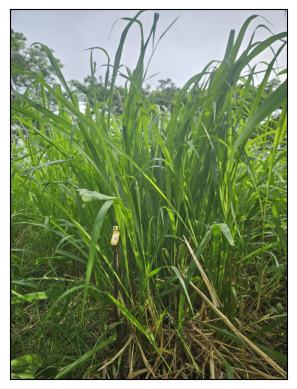

In [35]:
plt.xticks([]), plt.yticks([])
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

In [36]:
#ESCOGIENDO UN AREA CUADRADA
widthzz=50
testeox=right_clicks[:][1][1]
print(testeox)
img_square=img[right_clicks[:][0][0]:right_clicks[:][1][0],right_clicks[:][0][1]:right_clicks[:][1][1]+widthzz,:]

985


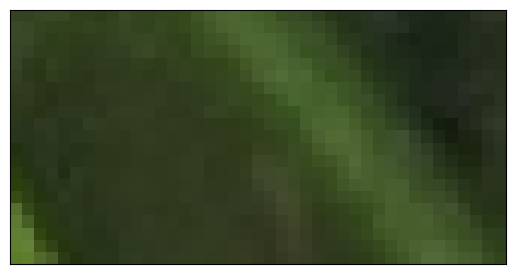

In [37]:
#PARA FILTRO USANDO UN CUADRO
plt.xticks([]), plt.yticks([])
plt.imshow(cv2.cvtColor(img_square, cv2.COLOR_BGR2RGB))
plt.show()

In [38]:
#AREA CUADRADA
#calculando el valor del color RBG en cada pixel Y Filtro Mahalanobis
r=0
g=1
b=2
imgrgb_r_all_square=[]
imgrgb_g_all_square=[]
imgrgb_b_all_square=[]
color_allsquare=[]
xcoord=np.linspace(right_clicks[:][0][0],right_clicks[:][1][0],right_clicks[:][1][0]-right_clicks[:][0][0]+1)
ycoord=np.linspace(right_clicks[:][0][1],right_clicks[:][1][1]+50,right_clicks[:][1][1]-right_clicks[:][0][1]+widthzz+1)
right_clicks_square=[]
for i in range(0, len(xcoord)):
    for j in range(0, len(ycoord)):
        clicks=list([xcoord[i],ycoord[j]])
        right_clicks_square.append(clicks)       
for i in range(0, len(right_clicks_square)):
    pixel_xy=right_clicks_square [i]
    pixel_x=int(pixel_xy[0])
    pixel_y=int(pixel_xy[1])
    imgrgb_rr =int(img[pixel_x,pixel_y, r])
    imgrgb_gg =int(img[pixel_x,pixel_y, g])
    imgrgb_bb =int(img[pixel_x,pixel_y, b])
    imgrgb_r_all_square.append(imgrgb_rr)  #valor del verde (R, red) en cada pixel
    imgrgb_g_all_square.append(imgrgb_gg)  #valor del verde (G, green) en cada pixel
    imgrgb_b_all_square.append(imgrgb_bb)  #valor del verde (B, blue) en cada pixel
    color= [img[pixel_x,pixel_y, r], img[pixel_x,pixel_y, g], img[pixel_x,pixel_y, b]]
    color_allsquare.append(color) #arreglo de colores
    color_allrgb=np.array(color_allsquare)
    #FILTRO MAHALANOBIS AREA CUADRADA
def repetir(A, veces):
    AA = []
    for elemento in A:
        AA.extend([elemento] * veces)
    return AA
R1=np.linspace(1, len(right_clicks_square), len(right_clicks_square))
R=np.reshape(repetir(R1, len(right_clicks_square)), (len(right_clicks_square), len(right_clicks_square)))
filtroMahalanobis=np.array([color_allrgb])
filtroMahalanobisCol=np.array(repetir(filtroMahalanobis, len(right_clicks_square)))

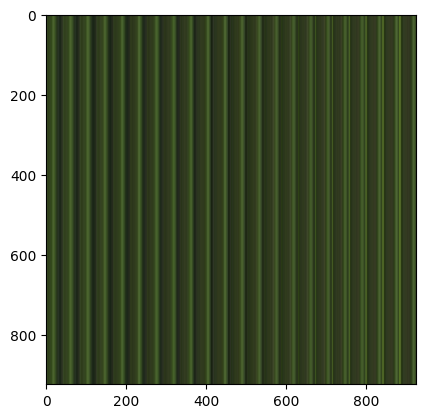

In [39]:
#PLOT DEL FILTRO DE MAHALANOBIS
plt.imshow(cv2.cvtColor(filtroMahalanobisCol, cv2.COLOR_BGR2RGB))
plt.show()

In [40]:
#matriz de covarianza normalizada para aplicar Mahalanobis
MCov_click=inv(np.cov(color_allrgb.T))
MCov_nor=MCov_click/np.max(np.max(MCov_click))
#MCov_nor=np.array([[1, 0, 0],[0, 1, 0],[0, 0, 1]]) #Algoritmo de distancia Euclidiana
colormedio=np.array([np.mean(color_allrgb[:,r]),np.mean(color_allrgb[:,g]), np.mean(color_allrgb[:,b])])
#escogiendo un punto de la imagen
pix_x_choose=10
pix_y_choose=10
puntoimag=img[pix_x_choose,pix_y_choose,:]
mahal_dist= distance.mahalanobis(puntoimag, colormedio, MCov_nor)
Apix_totalx=np.shape(img)[0]
Apix_totaly=np.shape(img)[1]
#calculo del filtro mahalanobis
img3=img
#img4=img
mahal_distIMall=[]
for i in range(0, Apix_totalx):
    for j in range(0, Apix_totaly):
        IM= [img[i, j, r], img[i, j, g], img[i, j, b]]
        mahal_distIM= distance.mahalanobis(IM, colormedio, MCov_nor)
        mahal_distIMall.append(mahal_distIM)
        if mahal_distIM >=30:
            img3[i,j,:]=np.array([0, 0, 0])
            #img4[i,j,:]=np.array([255, 255, 255])

In [41]:
print(np.max(mahal_distIMall))
print(np.min(mahal_distIMall))

117.08151663366827
0.44684797360805356


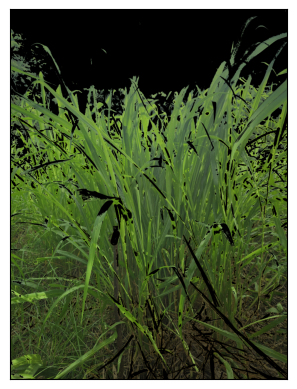

In [42]:
plt.xticks([]), plt.yticks([])
plt.imshow(cv2.cvtColor(img3[:,:,:], cv2.COLOR_BGR2RGB))
plt.show()

In [43]:
testreshape= np.reshape(img3, (img3.shape[0] * img3.shape[1], 3))
testreshape2=list(np.reshape(testreshape,3*img3.shape[0]*img3.shape[1]))
zeros_imag=len([x for x in testreshape2 if x == 0])
print(zeros_imag)

11308599


In [44]:
mean_pixel_segmentednozero=np.sum(img3[:,:,g])/(img3.shape[0]*img3.shape[1]-np.floor(zeros_imag/3))
print(mean_pixel_segmentednozero) #media pix segmentado

99.81958702950878


In [45]:
mean_pixel_segmented=np.mean(img3[:,:,g])
print(mean_pixel_segmented)

68.46348475


In [46]:
pixel_segmented=([np.mean(img3[:,:,r]), np.max([mean_pixel_segmentednozero, mean_pixel_segmented]), np.mean(img3[:,:,b])])
print(pixel_segmented) #maximo verdor
print(colormedio) #media de 10 puntos
print([pixel_segmented[1], colormedio[1]])
desv=pixel_segmented[1] - colormedio[1]
print(np.abs(desv))
print([pixel_segmented[1]/255, colormedio[1]/255])
desv_norm=pixel_segmented[1]/255 - colormedio[1]/255
print(np.abs(desv_norm))

[31.2183995, 99.81958702950878, 52.52385725]
[32.37012987 64.99675325 50.56709957]
[99.81958702950878, 64.99675324675324]
34.82283378275554
[0.39144936090003446, 0.25488922841864015]
0.13656013248139431
